In [66]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from pydantic import Field, BaseModel
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [67]:
model = ChatOpenAI(model_name='gpt-4o-mini', temperature=0)


In [68]:
class EvaluationSchema(BaseModel):
    feedback: Annotated[str, Field(description="Provide feedback on the answer provided.")]
    score : Annotated[int, Field(description="Score the answer on a scale of 1 to 10.")]

In [69]:
structured_model = model.with_structured_output(EvaluationSchema)

In [70]:
template = """Generate a detailed essay on this topic: {topic}."""

prompt = template.format(topic="Indian Cricket Team")

essay = model.invoke(prompt)

essay

AIMessage(content="### The Indian Cricket Team: A Journey Through Glory and Challenges\n\nCricket is not just a sport in India; it is a passion that unites millions across the subcontinent. The Indian cricket team, often referred to as the Men in Blue, has become a symbol of national pride and unity. From its humble beginnings to becoming a powerhouse in international cricket, the journey of the Indian cricket team is a tale of perseverance, talent, and the relentless pursuit of excellence.\n\n#### Historical Background\n\nThe origins of cricket in India can be traced back to the 18th century when British colonizers introduced the game. The first recorded match took place in 1721, but it wasn't until the late 19th century that organized cricket began to take shape. The formation of the Bombay Cricket Association in 1890 marked a significant milestone, leading to the establishment of regional teams and competitions.\n\nIndia's first official Test match was played against England in 1932

In [71]:
class UPSCSchema(TypedDict):
    essay : str
    language_feedback: str
    content_feedback: str
    thought_feedback: str
    Overall_feedback: str
    individual_score: Annotated[list[int], operator.add]
    avg_score: float


In [72]:
def evaluate_language(state: UPSCSchema):
    prompt = f"Provide feedback on the language used in the essay: {state['essay']}"
    result = structured_model.invoke(prompt)
    return {
        'language_feedback': result.feedback,
        'individual_score': [result.score]
    }

In [73]:
def evaluate_content(state: UPSCSchema):
    prompt = f"Provide feedback on the content quality of the essay: {state['essay']}"
    result = structured_model.invoke(prompt)
    return {
        'content_feedback': result.feedback,
        'individual_score': [result.score]
    }

In [74]:
def evaluate_clarity(state: UPSCSchema):
    prompt = f"Provide feedback on the clarity of the essay: {state['essay']}"
    result = structured_model.invoke(prompt)
    return {
        'thought_feedback': result.feedback,
        'individual_score': [result.score],
    }

In [75]:
# ...existing code...
def overall_evaluation(state: UPSCSchema):
    prompt = (
        "Based on the following feedbacks, provide an overall feedback:\n"
        f"Language Feedback: {state['language_feedback']}\n"
        f"Content Feedback: {state['content_feedback']}\n"
        f"Clarity Feedback: {state['thought_feedback']}"
    )
    result = structured_model.invoke(prompt)
    scores = state.get('individual_score', [])
    avg_score = sum(scores) / len(scores) if scores else 0.0
    return {
        'Overall_feedback': result.feedback,
        'avg_score': avg_score
    }
# ...existing code...

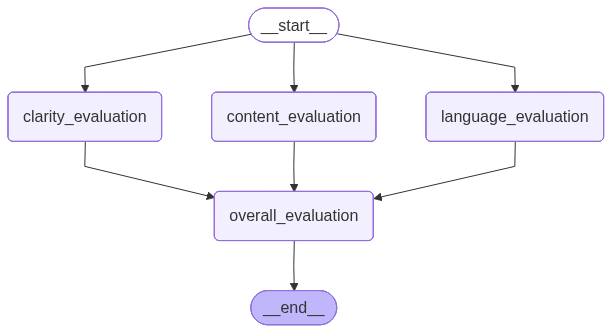

In [76]:
graph = StateGraph(UPSCSchema)

graph.add_node("language_evaluation", evaluate_language)
graph.add_node("content_evaluation", evaluate_content)
graph.add_node("clarity_evaluation", evaluate_clarity)
graph.add_node("overall_evaluation", overall_evaluation)

graph.add_edge(START,"language_evaluation")
graph.add_edge(START,"content_evaluation")
graph.add_edge(START,"clarity_evaluation")

graph.add_edge("language_evaluation","overall_evaluation")
graph.add_edge("content_evaluation","overall_evaluation")
graph.add_edge("clarity_evaluation","overall_evaluation")

graph.add_edge("overall_evaluation",END)

workflow = graph.compile()

workflow

In [77]:
initial_state: UPSCSchema = {
    'essay': essay,
    'language_feedback': '',
    'content_feedback': '',
    'thought_feedback': '',
    'Overall_feedback': '',
    'individual_score': [],
    'avg_score': 0.0
}

final_state = workflow.invoke(initial_state)

final_state

{'essay': AIMessage(content="### The Indian Cricket Team: A Journey Through Glory and Challenges\n\nCricket is not just a sport in India; it is a passion that unites millions across the subcontinent. The Indian cricket team, often referred to as the Men in Blue, has become a symbol of national pride and unity. From its humble beginnings to becoming a powerhouse in international cricket, the journey of the Indian cricket team is a tale of perseverance, talent, and the relentless pursuit of excellence.\n\n#### Historical Background\n\nThe origins of cricket in India can be traced back to the 18th century when British colonizers introduced the game. The first recorded match took place in 1721, but it wasn't until the late 19th century that organized cricket began to take shape. The formation of the Bombay Cricket Association in 1890 marked a significant milestone, leading to the establishment of regional teams and competitions.\n\nIndia's first official Test match was played against Engla